# Machine Learning — Bike Sharing

Este notebook apresenta a etapa de modelagem preditiva dos dados de aluguel de bicicletas, com o objetivo de desenvolver modelos capazes de prever a demanda por aluguéis nas próximas 24 horas.

A partir dos padrões identificados na análise exploratória, serão utilizadas variáveis temporais, climáticas e informações sobre o comportamento recente da demanda. Também serão avaliadas diferentes abordagens de modelagem e métricas de desempenho, buscando identificar quais modelos apresentam melhores resultados para o problema de previsão.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_PATH = '../data/'
file_name = 'bike_sharing_silver.csv'

df = pd.read_csv(DATA_PATH+file_name, sep=',')
df_copy = df.copy()
df_sim_real = df.iloc[-192:]
df = df.iloc[:-192]

df.head()

,instant,season,year,month,hour,holiday,weekday,working_day,weather_sit,temp,feeling_temp,hum,wind_speed,casual,registered,datetime,cnt
0,1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,2011-01-01 00:00:00,16
1,2,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,2011-01-01 01:00:00,40
2,3,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,2011-01-01 02:00:00,32
3,4,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,2011-01-01 03:00:00,13
4,5,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,2011-01-01 04:00:00,1


In [3]:
TARGET_COLUMN = 'cnt'
NUMERIC_COLUMNS = ['temp', 'feeling_temp', 'hum', 'wind_speed', 'casual', 'registered']
CATEGORICAL_COLUMNS = ['holiday', 'weekday', 'working_day', 'weather_sit']
DATETIME_COLUMN = 'datetime'

# Rolling Features

As rolling features permitem resumir o comportamento recente da demanda em diferentes janelas de tempo. A média e a mediana representam o nível central da demanda, enquanto o desvio-padrão representa sua variabilidade. Já os valores mínimo e máximo indicam os extremos observados dentro da janela.

Foram criadas as rolling features: média, mediana, desvio-padrão, mínimo e máximo para as janelas de 6, 24 e 168 observações. A janela de 6 observações representa o comportamento mais recente, enquanto as janelas de 24 e 168 observações permitem capturar comportamentos relacionados aos padrões diário e semanal identificados na análise da série.

Para evitar vazamento de informação, as estatísticas foram calculadas utilizando somente valores anteriores ao instante que será previsto, sem incluir informações futuras.

In [4]:
def create_rolling_features(df, windows):
    
    for window in windows:
        mean_column = 'rolling_mean_' + str(window)
        median_column = 'rolling_median_' + str(window)
        std_column = 'rolling_std_' + str(window)
        min_column = 'rolling_min_' + str(window)
        max_column = 'rolling_max_' + str(window)
        
        df[mean_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).mean()
        
        df[median_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).median()
        
        df[std_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).std()
        
        df[min_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).min()
        
        df[max_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).max()
    
    return df

windows = [6, 24, 168]
df = create_rolling_features(df, windows)
df.shape

(17187, 32)

### Lags

As variáveis de lag permitem utilizar valores anteriores da demanda como informações para a previsão, incorporando ao modelo a dependência temporal existente na série. Diferentemente das rolling features, que resumem um conjunto de observações, cada lag representa o valor da demanda em um ponto específico do passado.

Foram criadas as variáveis `lag_1`, `lag_6`, `lag_24` e `lag_168`. O `lag_1` representa a demanda da hora anterior, enquanto o `lag_6` representa a demanda observada seis horas antes. Já os `lag_24` e `lag_168` permitem utilizar, respectivamente, a demanda do mesmo horário do dia anterior e da semana anterior, considerando os padrões diário e semanal identificados na análise da série.

A criação desses lags foi baseada nos padrões de autocorrelação observados durante a análise exploratória, especialmente nas defasagens relacionadas ao comportamento diário e semanal. Dessa forma, essas variáveis permitem que o modelo utilize informações recentes e padrões recorrentes da demanda para realizar as previsões.

In [5]:
def create_lags(df, lags):
    
    for lag in lags:
            df[f'lag_{lag}'] = df[TARGET_COLUMN].shift(lag)

    return df

lags = [1, 2, 8, 24, 72, 168]
df = create_lags(df, lags)
df.shape

(17187, 38)

## Seleção das variáveis

Antes do treinamento dos modelos, foram removidas as colunas `casual`, `registered`, `temp`, `datetime` e `weekday` do conjunto de dados utilizado no treinamento.

A remoção foi realizada com base nos motivos identificados durante a análise exploratória, considerando redundância entre variáveis, risco de vazamento de informação, características temporais já representadas por outras variáveis e informações que não serão utilizadas diretamente pelo modelo.


In [6]:
df_ml = df.drop(columns=['casual', 'registered', 'temp', 'weekday']).iloc[168:]
df_ml

,instant,season,year,month,hour,holiday,working_day,weather_sit,feeling_temp,hum,...,rolling_median_168,rolling_std_168,rolling_min_168,rolling_max_168,lag_1,lag_2,lag_8,lag_24,lag_72,lag_168
168,169,1,0,1,7,0,0,2,0.1818,0.74,...,49.0,51.220768,1.0,219.0,2.0,5.0,15.0,84.0,3.0,16.0
169,170,1,0,1,8,0,0,3,0.1818,0.93,...,49.0,51.256712,1.0,219.0,9.0,2.0,25.0,210.0,33.0,40.0
170,171,1,0,1,9,0,0,3,0.1818,0.93,...,49.0,51.340879,1.0,219.0,15.0,9.0,16.0,134.0,88.0,32.0
171,172,1,0,1,10,0,0,2,0.1970,0.80,...,49.0,51.383175,1.0,219.0,20.0,15.0,16.0,63.0,195.0,13.0
172,173,1,0,1,11,0,0,2,0.1818,0.69,...,50.5,51.274881,1.0,219.0,61.0,20.0,7.0,67.0,115.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17182,17183,1,1,12,17,0,0,1,0.3182,0.49,...,125.5,154.215062,3.0,678.0,190.0,137.0,56.0,114.0,475.0,243.0
17183,17184,1,1,12,18,0,0,1,0.3030,0.45,...,121.0,154.125904,3.0,678.0,114.0,190.0,93.0,82.0,381.0,107.0
17184,17185,1,1,12,19,0,0,1,0.3333,0.42,...,121.0,154.158688,3.0,678.0,93.0,114.0,152.0,60.0,118.0,109.0
17185,17186,1,1,12,20,0,0,1,0.3030,0.65,...,121.0,154.310331,3.0,678.0,58.0,93.0,196.0,61.0,50.0,122.0


# Salva o dataframe de treino

In [7]:
df_ml.to_csv(DATA_PATH+'df_ml.csv', index=False, sep=',')

# Separação dos dados de treino e teste

Os dados foram separados respeitando a ordem cronológica das observações. Em séries temporais, não é adequado realizar uma divisão aleatória entre treino e teste, pois isso poderia fazer com que o modelo fosse treinado com informações de períodos posteriores ao período utilizado para avaliação.

Para evitar esse problema, foi utilizado o `TimeSeriesSplit`, que realiza divisões sequenciais dos dados. Em cada divisão, o modelo é treinado utilizando apenas as observações anteriores e avaliado em um período posterior.

Essa abordagem simula melhor o cenário real de previsão, no qual utilizamos dados históricos para prever valores futuros, além de permitir avaliar a consistência do modelo em diferentes períodos da série.


In [8]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=24)

X = df_ml.drop(columns=[TARGET_COLUMN, 'datetime'])
y = df_ml[TARGET_COLUMN]

splits = list(tscv.split(X))

## Métricas de avaliação

* MAE (Mean Absolute Error): representa o erro absoluto médio entre os valores reais e os valores previstos. Quanto menor o MAE, menor é o erro médio das previsões.

* RMSE (Root Mean Squared Error): calcula a raiz do erro quadrático médio. Como ele dá maior peso aos erros maiores, valores elevados indicam a presença de previsões com erros mais acentuados. Quanto menor o RMSE, melhor o desempenho.

* MAPE (Mean Absolute Percentage Error): representa o erro absoluto médio em proporção. Facilita a interpretação do erro em relação ao valor real. Quanto menor o MAPE, menor é o erro percentual médio.

* R² (Coeficiente de Determinação): indica a proporção da variação da variável alvo que é explicada pelo modelo. Seu valor pode variar de menos infinito a 1, sendo que valores mais próximos de 1 indicam maior capacidade de explicar a variação observada.


In [10]:
SEED = 42

def fit_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return metrics

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor


models = {
    'Linear Regression': LinearRegression(n_jobs=6),
    'Decision Tree': DecisionTreeRegressor(random_state=SEED),
    'Random Forest': RandomForestRegressor(random_state=SEED, n_jobs=6),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED),
    'XGBoost': XGBRegressor(random_state=SEED)
}

results = []

for model_name, model in models.items():
    fold_metrics = []

    for train_index, test_index in splits:
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        metrics = fit_model(model, X_train, y_train, X_test, y_test)
        fold_metrics.append(metrics)

    average_metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    average_metrics['Model'] = model_name

    results.append(average_metrics)

metrics_df = pd.DataFrame(results)

# Comparação dos modelos

O Random Forest apresentou o melhor desempenho entre os modelos avaliados. Ele obteve o menor MAE (20,66), o menor MAPE (0,2768) e o segundo menor RMSE (33,31), indicando menores erros nas previsões. Além disso, apresentou o segundo maior R² (0,8664), indicando que o modelo conseguiu explicar uma maior proporção da variação observada na demanda.

Em comparação, os demais modelos apresentaram valores de erro superiores e R² inferior. Dessa forma, com base nas métricas utilizadas nesta etapa de validação, o Random Forest apresentou o melhor desempenho preditivo entre os modelos avaliados.

In [12]:
metrics_df

,MAE,RMSE,MAPE,R2,Model
0,42.263729,55.889699,1.050691,0.541221,Linear Regression
1,25.841667,39.702303,0.358395,0.748114,Decision Tree
2,20.660500,33.308369,0.276774,0.866431,Random Forest
3,27.854503,42.499835,0.559201,0.619915,Gradient Boosting
4,21.665125,32.408407,0.427174,0.890307,XGBoost


# Análise dos folds

Foram analisados os resultados de cada fold do Random Forest para verificar a consistência do desempenho ao longo dos diferentes períodos de validação e identificar possíveis sinais de overfitting.

As métricas apresentaram alguma variação entre os folds, principalmente no terceiro, que apresentou os maiores valores de MAE (26,38), RMSE (43,47) e MAPE (0,4364). Apesar dessa variação, o modelo manteve R² acima de 0,76 e valores de erro relativamente próximos nos diferentes períodos avaliados.

Dessa forma, os resultados não indicam uma perda acentuada de desempenho entre os folds, sugerindo que o Random Forest apresenta desempenho relativamente consistente ao longo dos períodos de validação.

In [13]:
fold_metrics = []

for fold, (train_index, test_index) in enumerate(splits, start=1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    metrics = fit_model(
        RandomForestRegressor(random_state=SEED,n_jobs=6),
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics['Fold'] = fold
    fold_metrics.append(metrics)

df_rf_metric = pd.DataFrame(fold_metrics)

df_rf_metric

,MAE,RMSE,MAPE,R2,Fold
0,15.192083,22.273194,0.144806,0.985104,1
1,24.657917,44.045301,0.221599,0.921109,2
2,26.378333,43.468026,0.436447,0.879210,3
3,19.227500,25.793930,0.342172,0.781820,4
4,17.846667,30.961392,0.238848,0.764910,5


# Ajuste de hiperparâmetros com Grid Search

Foi realizada uma busca de hiperparâmetros utilizando GridSearchCV, a métrica escolhida como critério foi RMSE, para avaliar diferentes combinações do Random Forest.

A configuração selecionada apresentou MAE de 20,18, RMSE de 32,41, MAPE de 0,26 e R² de 0,88 no conjunto de avaliação.

Com base nos resultados obtidos, essa configuração será utilizada na etapa seguinte do projeto.

In [46]:
from sklearn.model_selection import GridSearchCV

def do_grid_seach(param_grid):
    rf = RandomForestRegressor(random_state=SEED)
        
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=splits,
        scoring='neg_root_mean_squared_error',
        n_jobs=6
    )
        
    grid_search.fit(X, y)
        
    cv_results = pd.DataFrame(grid_search.cv_results_)

    return cv_results

param_grid = {
    # A quantidade de parâmetros foi reduzida devido ao tempo de execução
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5]
}

cv_results = do_grid_seach(param_grid)

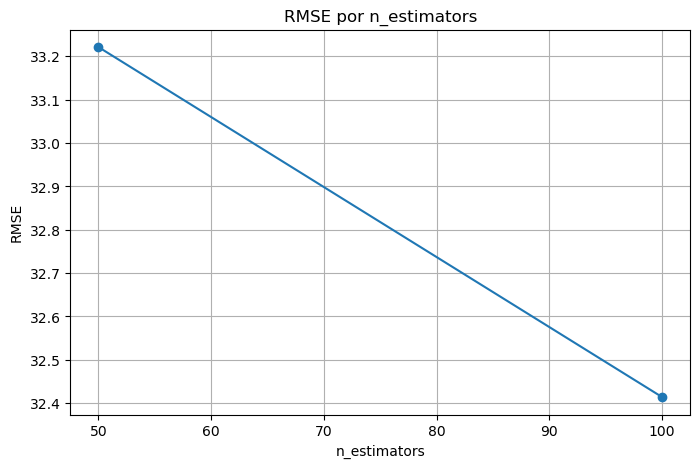

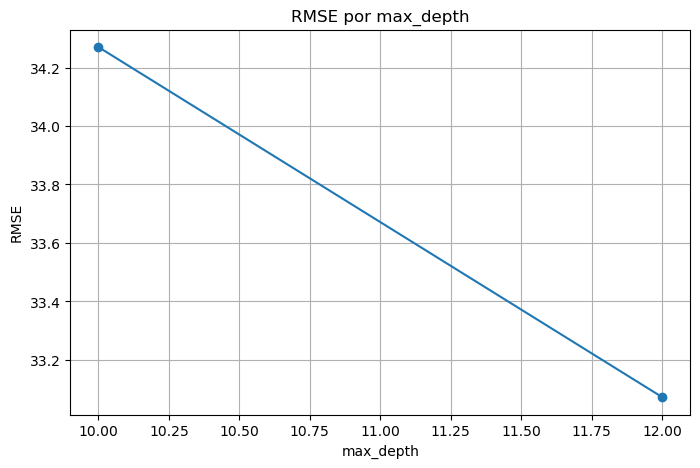

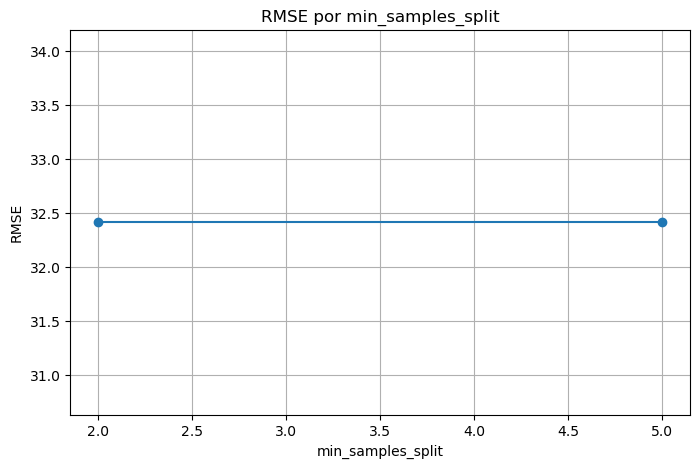

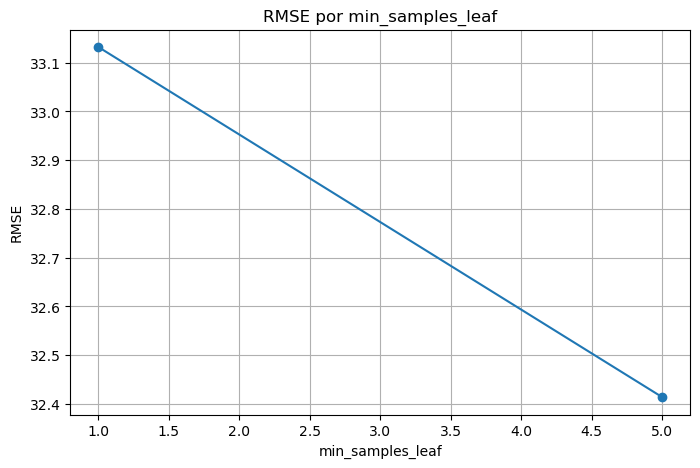

In [47]:
parameters = [
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]

for parameter in parameters:
    grouped_results = cv_results.groupby(parameter)['mean_test_score'].max().reset_index()
    grouped_results['RMSE'] = -grouped_results['mean_test_score']

    plt.figure(figsize=(8, 5))
    plt.plot(grouped_results[parameter], grouped_results['RMSE'], marker='o')
    plt.xlabel(parameter.replace('param_', ''))
    plt.ylabel('RMSE')
    plt.title(f'RMSE por {parameter.replace("param_", "")}')
    plt.grid(True)
    plt.show()

In [14]:
def rf_metrics(rf):
    
    fold_metrics = []
    
    for fold, (train_index, test_index) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_test)
    
        metrics = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
            'MAPE': mean_absolute_percentage_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        }
    
        fold_metrics.append(metrics)
    
    rf_best_metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    df_rf_best_metrics = pd.DataFrame([rf_best_metrics])
    
    return df_rf_best_metrics

In [15]:
rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=6
)

rf_metrics(rf_best)

,MAE,RMSE,MAPE,R2
0,20.184285,32.41385,0.255731,0.877294


# Análise de overfitting

A comparação entre o desempenho no treino e nos folds de validação temporal apresenta evidências de overfitting. Os valores de MAE, RMSE e R2 de treino e validação possuem diferenças a serem consideradas.

In [84]:
from sklearn.base import clone

def evaluate_train_validation(model):
    train_validation_metrics = []

    for fold, (train_index, test_index) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model_fold = clone(model)
        model_fold.fit(X_train, y_train)

        y_train_pred = model_fold.predict(X_train)
        y_test_pred = model_fold.predict(X_test)

        train_validation_metrics.append({
            'Fold': fold,
            'Train MAE': mean_absolute_error(y_train, y_train_pred),
            'Validation MAE': mean_absolute_error(y_test, y_test_pred),
            'Train RMSE': mean_squared_error(y_train, y_train_pred) ** 0.5,
            'Validation RMSE': mean_squared_error(y_test, y_test_pred) ** 0.5,
            'Train R2': r2_score(y_train, y_train_pred),
            'Validation R2': r2_score(y_test, y_test_pred)
        })

    train_validation_df = pd.DataFrame(train_validation_metrics)

    return train_validation_df

In [88]:
evaluate_train_validation(rf_best)

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,20.637125,17.680105,33.893888,27.079862,0.965450,0.977981
1,2,20.643421,24.181607,33.926638,46.634567,0.965385,0.911561
2,3,20.624824,25.788483,33.891220,42.474059,0.965444,0.884671
3,4,20.630147,19.050796,33.890530,25.613956,0.965423,0.784854
4,5,20.619298,19.749780,33.864140,32.116647,0.965453,0.747039


## Após nova busca de hiperparâmetros

As métricas do novo Random Forest ainda apresentam indícios de overfitting. Em alguns folds, observa-se uma diferença relevante entre os erros de treino e validação, principalmente no RMSE e no R². Além disso, o desempenho de validação varia entre os folds, indicando que o modelo apresenta dificuldades de generalização consistentes em diferentes períodos da série temporal.

Dessa forma, os resultados indicam que a nova configuração ainda não eliminou o problema de generalização observado anteriormente.

In [80]:
param_grid = {
    # A quantidade de parâmetros foi reduzida devido ao tempo de execução
    'n_estimators': [100],#[50, 100, 150, 200],
    'max_depth': [10],#[2, 5, 10, 20],
    'min_samples_split': [48, 72, 168, 720],
    'min_samples_leaf': [24]#[6, 12, 24, 48, 72] 
}

cv_results = do_grid_seach(param_grid)

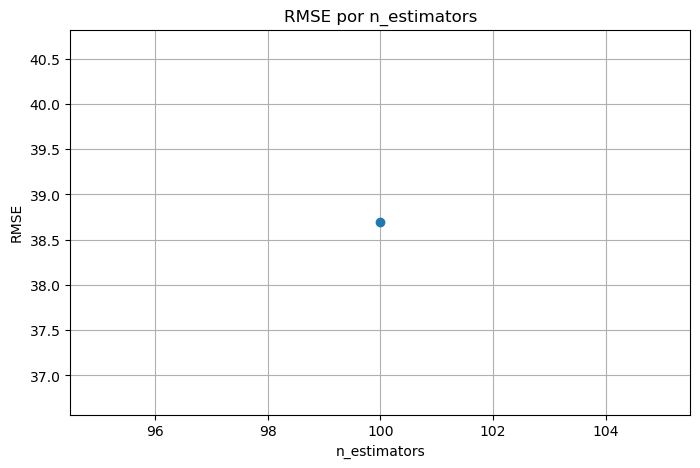

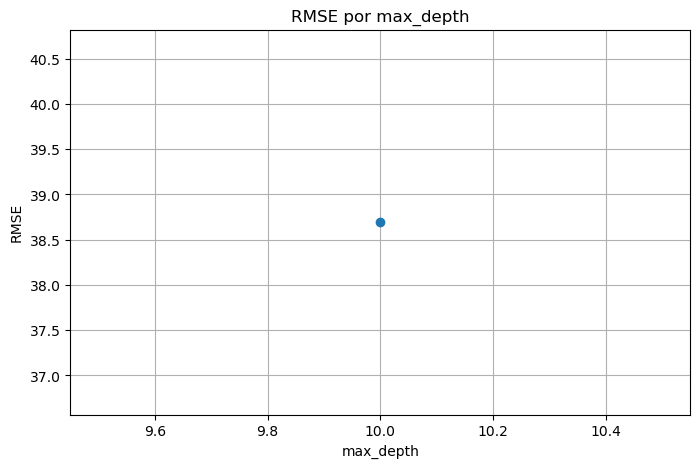

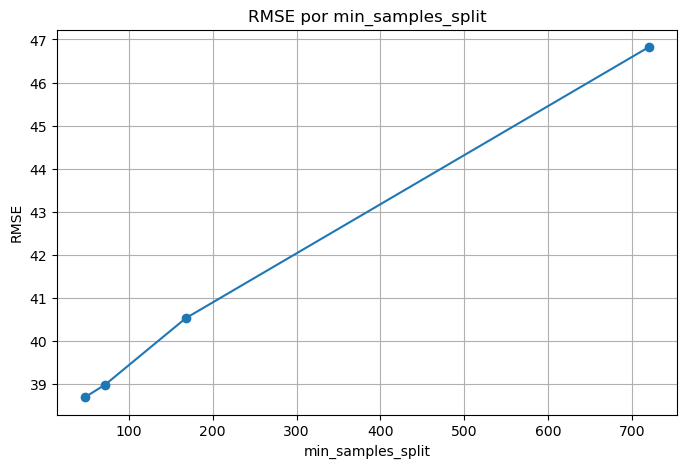

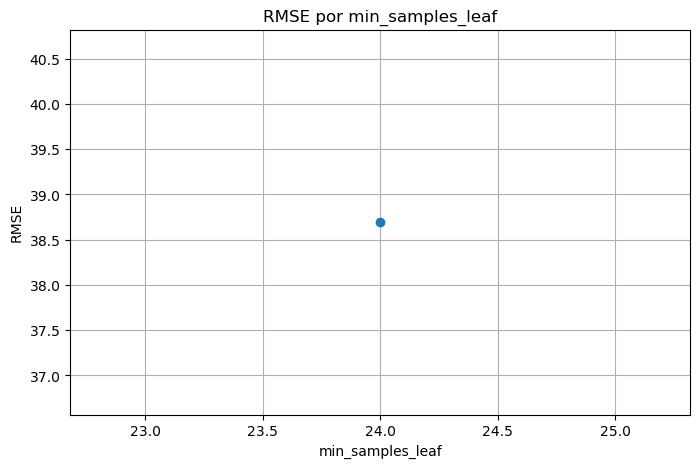

In [81]:
parameters = [
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]

for parameter in parameters:
    grouped_results = cv_results.groupby(parameter)['mean_test_score'].max().reset_index()
    grouped_results['RMSE'] = -grouped_results['mean_test_score']

    plt.figure(figsize=(8, 5))
    plt.plot(grouped_results[parameter], grouped_results['RMSE'], marker='o')
    plt.xlabel(parameter.replace('param_', ''))
    plt.ylabel('RMSE')
    plt.title(f'RMSE por {parameter.replace("param_", "")}')
    plt.grid(True)
    plt.show()

In [86]:
rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=24,
    min_samples_leaf=6,
    random_state=SEED,
    n_jobs=6
)

rf_metrics(rf_best)

,MAE,RMSE,MAPE,R2
0,21.290154,34.783818,0.267385,0.861221


In [89]:
evaluate_train_validation(rf_best)

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,20.637125,17.680105,33.893888,27.079862,0.965450,0.977981
1,2,20.643421,24.181607,33.926638,46.634567,0.965385,0.911561
2,3,20.624824,25.788483,33.891220,42.474059,0.965444,0.884671
3,4,20.630147,19.050796,33.890530,25.613956,0.965423,0.784854
4,5,20.619298,19.749780,33.864140,32.116647,0.965453,0.747039


## Evidências de overfitting no XGBoost

Após a avaliação do XGBoost utilizando validação temporal, também foram observadas diferenças relevantes entre as métricas de treino e validação. O modelo apresenta erros consideravelmente menores e R² próximo de 0,99 no treino, enquanto as métricas de validação apresentam maior variação entre os folds.

Esse comportamento indica que o XGBoost também apresenta sinais de overfitting, assim como observado anteriormente no Random Forest. Dessa forma, antes de realizar novas tentativas de ajuste dos modelos, será necessário avançar para uma etapa de feature engineering, buscando criar variáveis que representem melhor os padrões temporais e o comportamento da demanda, com potencial para melhorar a capacidade de generalização dos modelos.

In [90]:
xbg = XGBRegressor(random_state=SEED)

evaluate_train_validation(xbg)

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,13.189822,17.691874,18.527754,25.298037,0.989676,0.980784
1,2,13.204158,26.089073,18.581237,44.569943,0.989617,0.919219
2,3,13.243730,32.852390,18.722637,45.217242,0.989454,0.869293
3,4,13.256509,11.830401,18.869773,16.266295,0.989281,0.913233
4,5,13.275743,19.861889,18.779217,30.690519,0.989376,0.769006


# Análise dos erros do modelo ao longo do tempo

Após a avaliação do modelo, foi realizada uma análise dos erros ao longo do tempo para identificar possíveis padrões associados a diferentes períodos e condições. Foram analisados o erro por estação do ano, dia da semana, hora do dia, condição climática e nível de demanda, buscando identificar situações em que o modelo apresenta maior dificuldade nas previsões.

In [22]:
from sklearn.base import clone

error_list = []

test_size = 24
initial_train_size = 24 * 30

for start in range(initial_train_size, len(X) - test_size + 1, test_size):
    train_end = start
    test_end = start + test_size

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_test = X.iloc[train_end:test_end]
    y_test = y.iloc[train_end:test_end]

    model = clone(rf_best)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    fold_df = pd.DataFrame({
        'datetime': df.loc[X_test.index, 'datetime'],
        'y_true': y_test,
        'y_pred': y_pred
    })

    error_list.append(fold_df)

error_df = pd.concat(error_list, ignore_index=True)
error_df.shape

(16296, 3)

In [23]:
error_df['error'] = error_df['y_true'] - error_df['y_pred']
error_df['absolute_error'] = error_df['error'].abs()

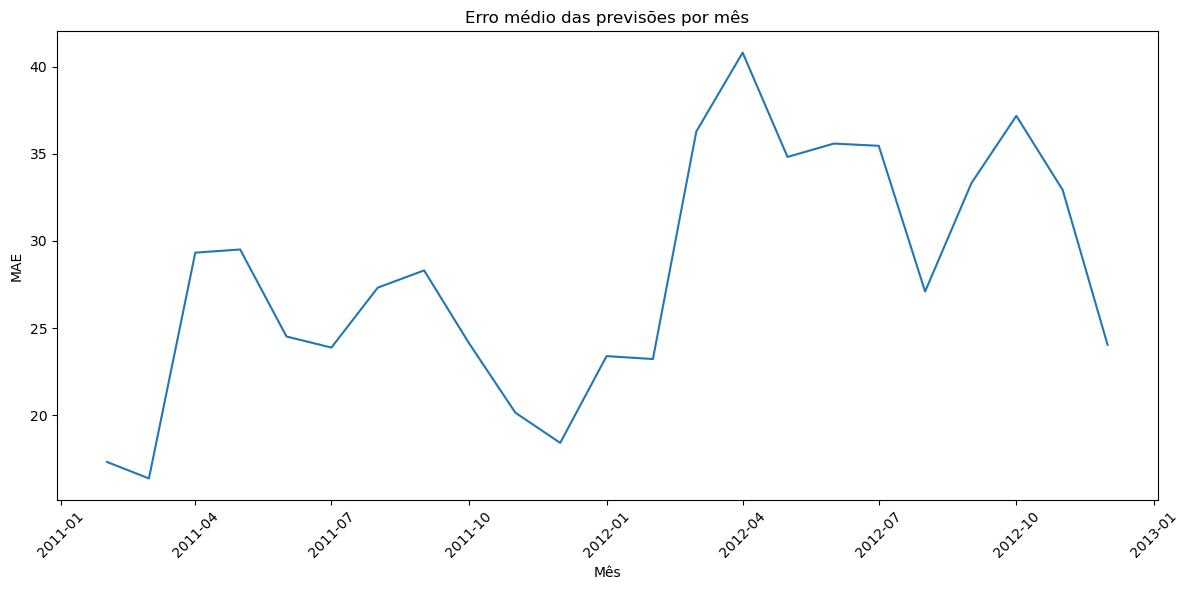

In [24]:
error_df['datetime'] = pd.to_datetime(error_df['datetime'])

monthly_error = (
    error_df
    .assign(month=error_df['datetime'].dt.to_period('M'))
    .groupby('month')[['absolute_error', 'y_true', 'y_pred']]
    .mean()
    .reset_index()
)

monthly_error['month'] = monthly_error['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly_error, x='month', y='absolute_error')

plt.xlabel('Mês')
plt.ylabel('MAE')
plt.title('Erro médio das previsões por mês')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Erro de acordo com a season

Foi analisado o erro absoluto médio das previsões de acordo com a estação do ano, buscando identificar se o desempenho do modelo varia entre as diferentes estações.


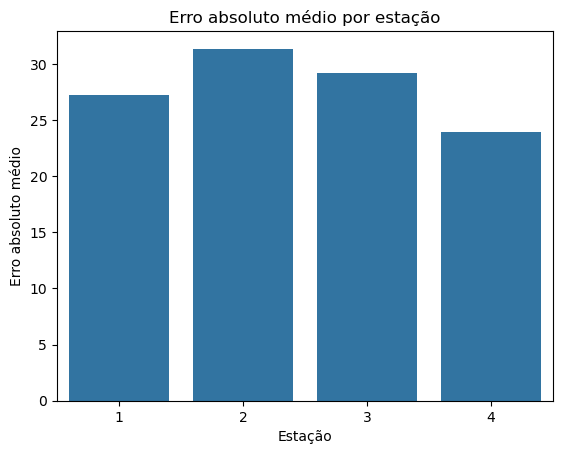

In [25]:
error_df['season'] = df.loc[error_df['datetime'].index, 'season']

def groupby_error(column):
    df = (
        error_df
        .groupby(column)['absolute_error']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    sns.barplot(
        data=df,
        x=column,
        y='absolute_error'
    )

groupby_error('season')
plt.xlabel('Estação')
plt.ylabel('Erro absoluto médio')
plt.title('Erro absoluto médio por estação')
plt.show()

## Erro por dia da semana

Foi analisado o erro absoluto médio das previsões para cada dia da semana, buscando identificar se o desempenho do modelo varia ao longo dos diferentes dias.

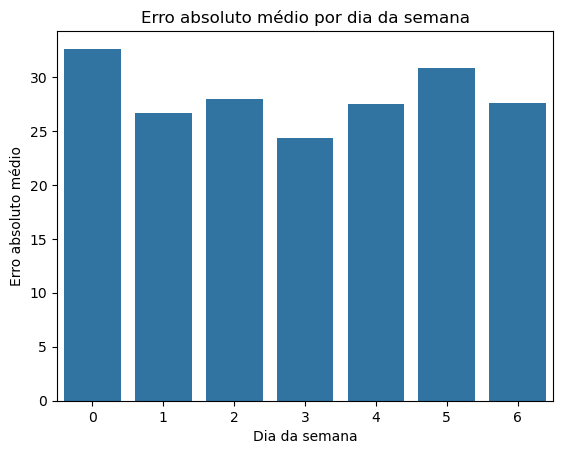

In [26]:
error_df['weekday'] = error_df['datetime'].dt.dayofweek

groupby_error('weekday')

plt.xlabel('Dia da semana')
plt.ylabel('Erro absoluto médio')
plt.title('Erro absoluto médio por dia da semana')
plt.show()

## Erro de acordo com as horas do dia

Foi analisado o erro absoluto médio das previsões para cada hora do dia, buscando identificar os horários em que o modelo apresenta maior dificuldade nas previsões.

Foram identificados picos de erro nas horas 8, 17 e 18, indicando maior dificuldade do modelo em realizar previsões nesses horários.

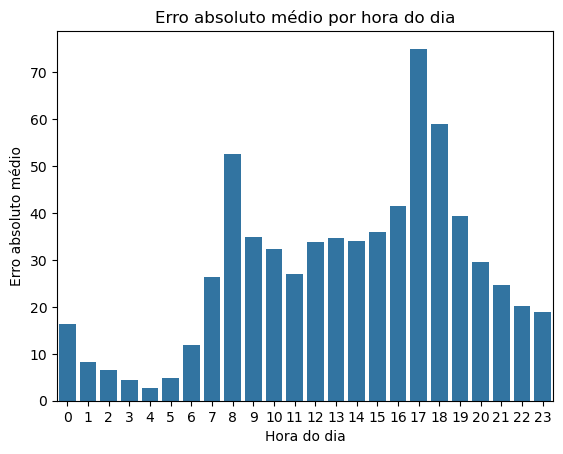

In [27]:
error_df['hour'] = error_df['datetime'].dt.hour

groupby_error('hour')

plt.xlabel('Hora do dia')
plt.ylabel('Erro absoluto médio')
plt.title('Erro absoluto médio por hora do dia')
plt.show()

## Condição climática

Foi analisado o erro absoluto médio das previsões de acordo com as diferentes condições climáticas, buscando identificar se o desempenho do modelo varia entre elas.

Foi identificado um pico de erro na condição climática 3, correspondente a neve fraca, chuva fraca ou condições similares.

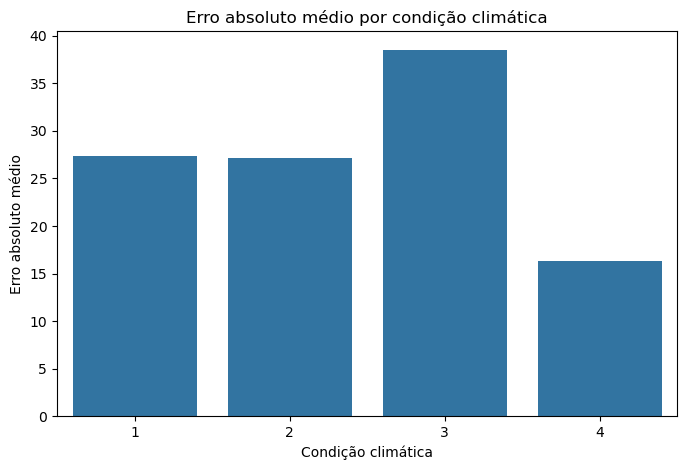

In [28]:
error_df['datetime'] = pd.to_datetime(error_df['datetime'])
df['datetime'] = pd.to_datetime(df['datetime'])

error_df = error_df.merge(
    df[['datetime', 'weather_sit']],
    on='datetime',
    how='left'
)

weather_error = (
    error_df
    .groupby('weather_sit', as_index=False)['absolute_error']
    .mean()
    .sort_values('absolute_error', ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_error,
    x='weather_sit',
    y='absolute_error',
    errorbar=None
)

plt.xlabel('Condição climática')
plt.ylabel('Erro absoluto médio')
plt.title('Erro absoluto médio por condição climática')
plt.show()

# Erro de acordo com a demanda

Foi analisado o erro absoluto médio das previsões de acordo com o nível de demanda, buscando identificar se o modelo apresenta maior dificuldade em períodos de alta ou baixa demanda.

Observou-se que o modelo apresenta maior erro nas previsões de alta demanda, indicando maior dificuldade em representar os períodos de maior volume de aluguéis.

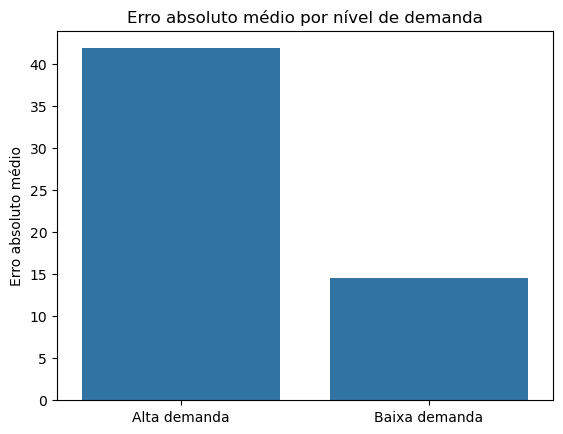

In [29]:
demand_median = error_df['y_true'].median()

error_df['demand_period'] = np.where(
    error_df['y_true'] >= demand_median,
    'Alta demanda',
    'Baixa demanda'
)

demand_error = (
    error_df
    .groupby('demand_period')['absolute_error']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=demand_error,
    x='demand_period',
    y='absolute_error',
    errorbar=None
)

plt.xlabel('')
plt.ylabel('Erro absoluto médio')
plt.title('Erro absoluto médio por nível de demanda')
plt.show()

## Comparação da demanda real x predita pelo modelo

Nesta etapa, comparamos os valores reais de demanda com os valores preditos pelo modelo ao longo do tempo, buscando identificar como as previsões se comportam em relação aos dados observados.

In [30]:
def plot_demand(df, x):
    plt.figure(figsize=(14, 6))

    sns.lineplot(
        data=df,
        x=x,
        y='y_true',
        label='Demanda real'
    )
    
    sns.lineplot(
        data=df,
        x=x,
        y='y_pred',
        label='Demanda prevista'
    )
    
    plt.xlabel('Data')
    plt.ylabel('Demanda')
    plt.title('Demanda real × demanda prevista no período de teste')
    plt.legend()
    plt.tight_layout()
    plt.show()

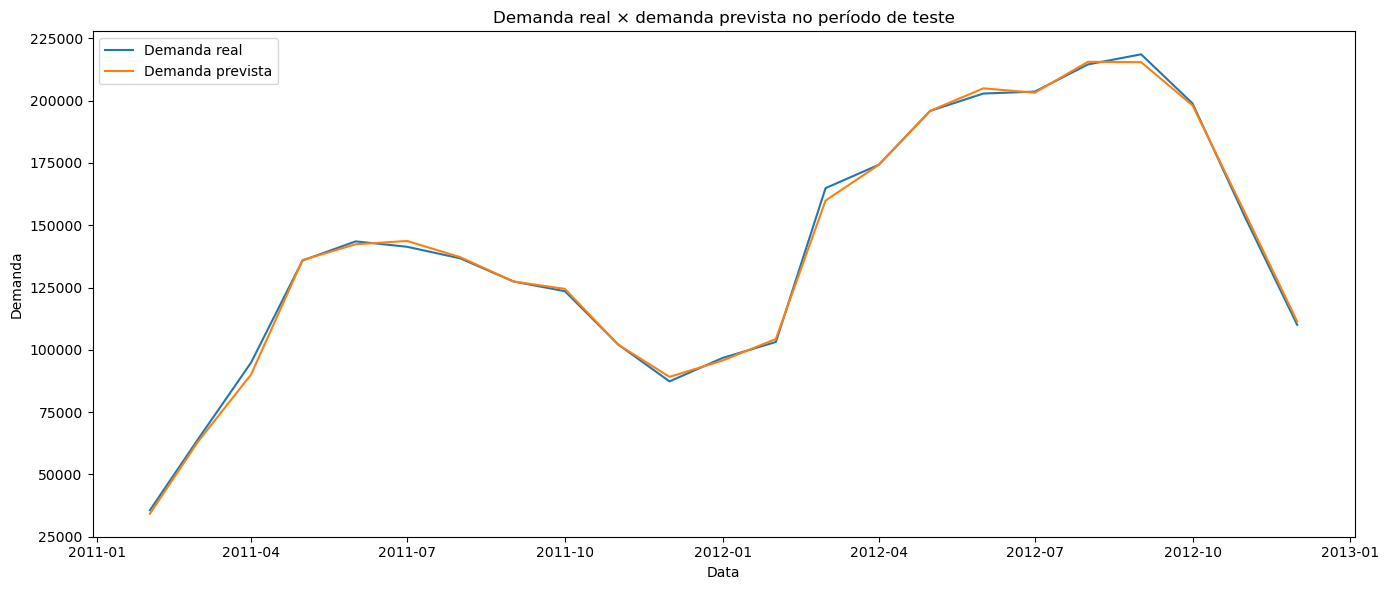

In [31]:
monthly_error = (
    error_df
    .assign(month=error_df['datetime'].dt.to_period('M'))
    .groupby('month')[['absolute_error', 'y_true', 'y_pred']]
    .sum()
    .reset_index()
)

monthly_error['month'] = monthly_error['month'].dt.to_timestamp()

plot_demand(monthly_error, 'month')


## Baixa demanda

Foi realizada uma análise da demanda real em comparação com a demanda predita durante um período de baixa demanda. Nesse recorte, as previsões acompanham as variações observadas na demanda real.

### Demanda em dezembro de 2011

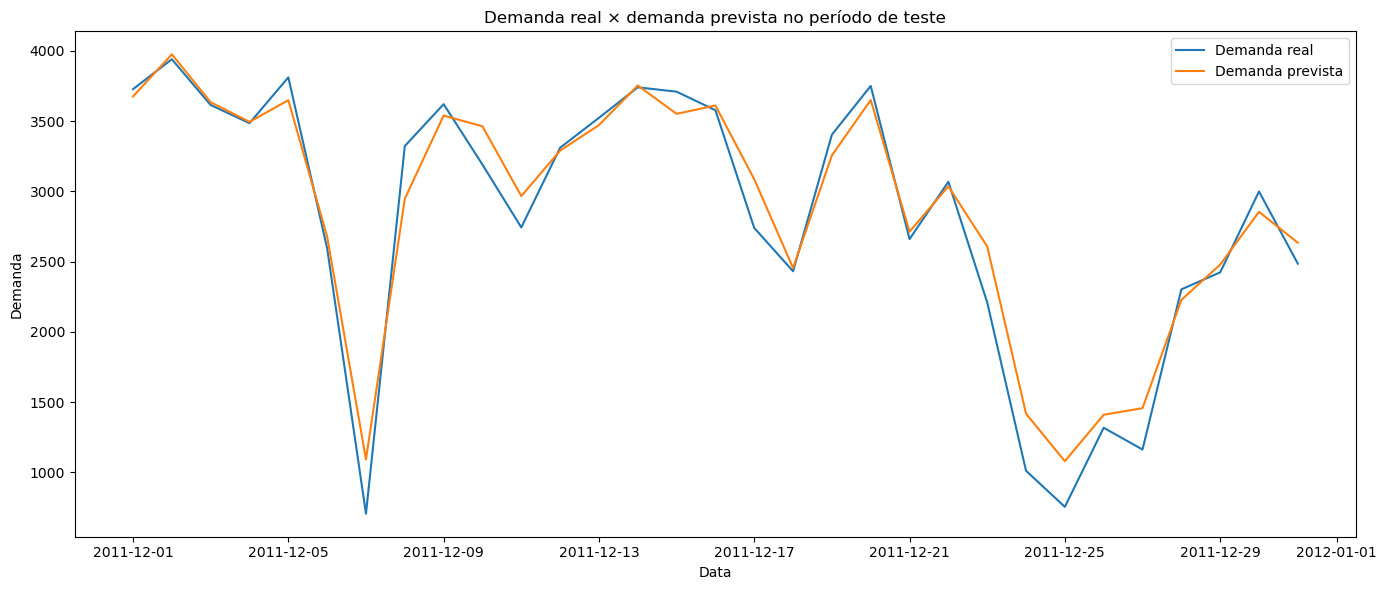

In [32]:
def demand_by_month(month, year):
    
    df_demand = error_df[(error_df['datetime'].dt.month == month) & (error_df['datetime'].dt.year == year)]
    
    df_demand = (
        df_demand
        .assign(day=df_demand['datetime'].dt.to_period('d'))
        .groupby('day')[['absolute_error', 'y_true', 'y_pred']]
        .sum()
        .reset_index()
    )
    
    df_demand['day'] = df_demand['day'].dt.to_timestamp()
    
    return df_demand

df_low_demand_by_day = demand_by_month(12, 2011)
plot_demand(df_low_demand_by_day, 'day')

### Demanda em dezembro de 2011 entre os dias 6 e 8

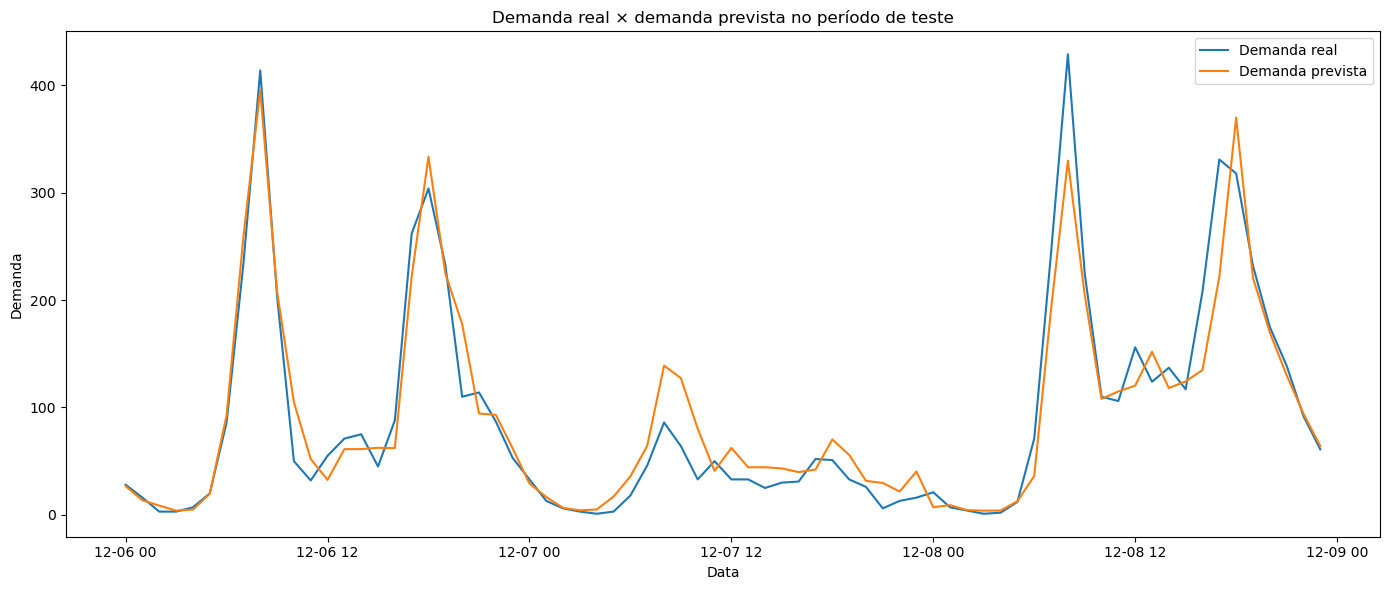

In [33]:
def demand_by_hour(year, month, start_day, end_day):
    
    df_demand = error_df[
    (error_df['datetime'].dt.year == year) &
    (error_df['datetime'].dt.month == month) &
    (error_df['datetime'].dt.day.between(start_day, end_day))
    ]
    
    df_demand = (
        df_demand
        .assign(hour=df_demand['datetime'].dt.to_period('h'))
        .groupby('hour')[['absolute_error', 'y_true', 'y_pred']]
        .sum()
        .reset_index()
    )
    
    df_demand['hour'] = df_demand['hour'].dt.to_timestamp()
    
    return df_demand

df_low_demand_by_hour = demand_by_hour(2011, 12, 6, 8)
plot_demand(df_low_demand_by_hour, 'hour')

## Alta demanda
Foi realizada uma análise da demanda real em comparação com a demanda predita durante um período de alta demanda. Nesse recorte, as previsões acompanham as variações observadas na demanda real.

### Demanda em setembro de 2012

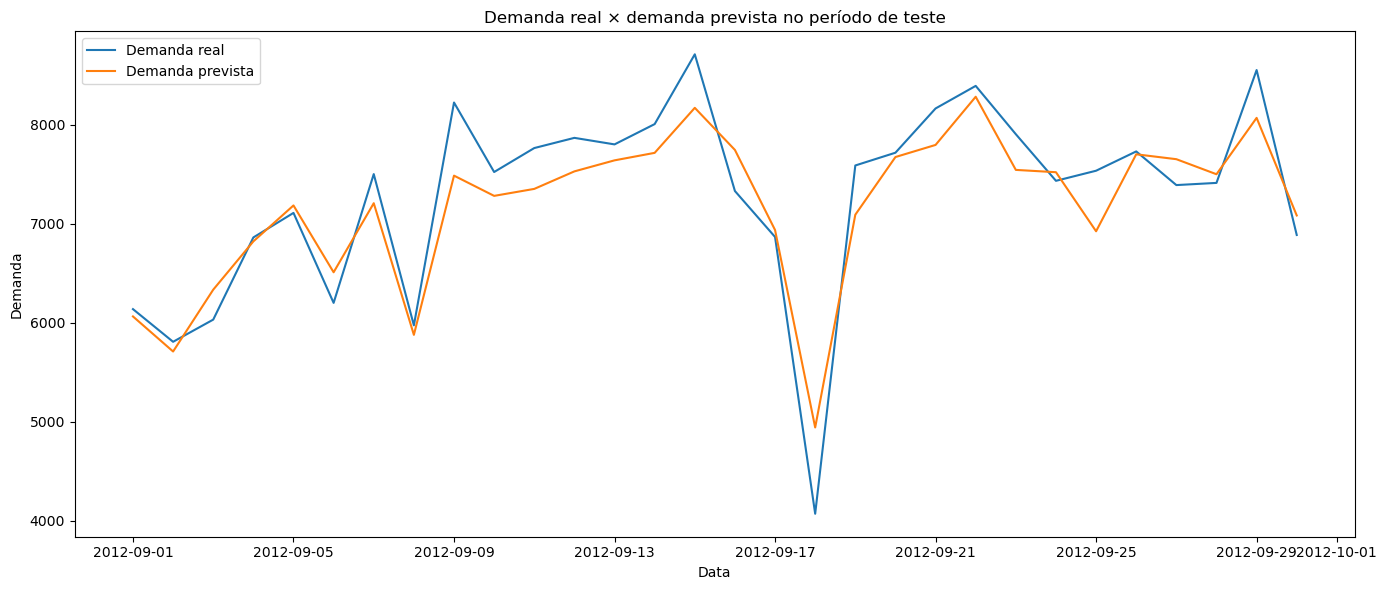

In [36]:
df_high_demand_by_day = demand_by_month(9, 2012)
plot_demand(df_high_demand_by_day, 'day')

### Demanda em setembro de 2012 entre os dias 14 e 16

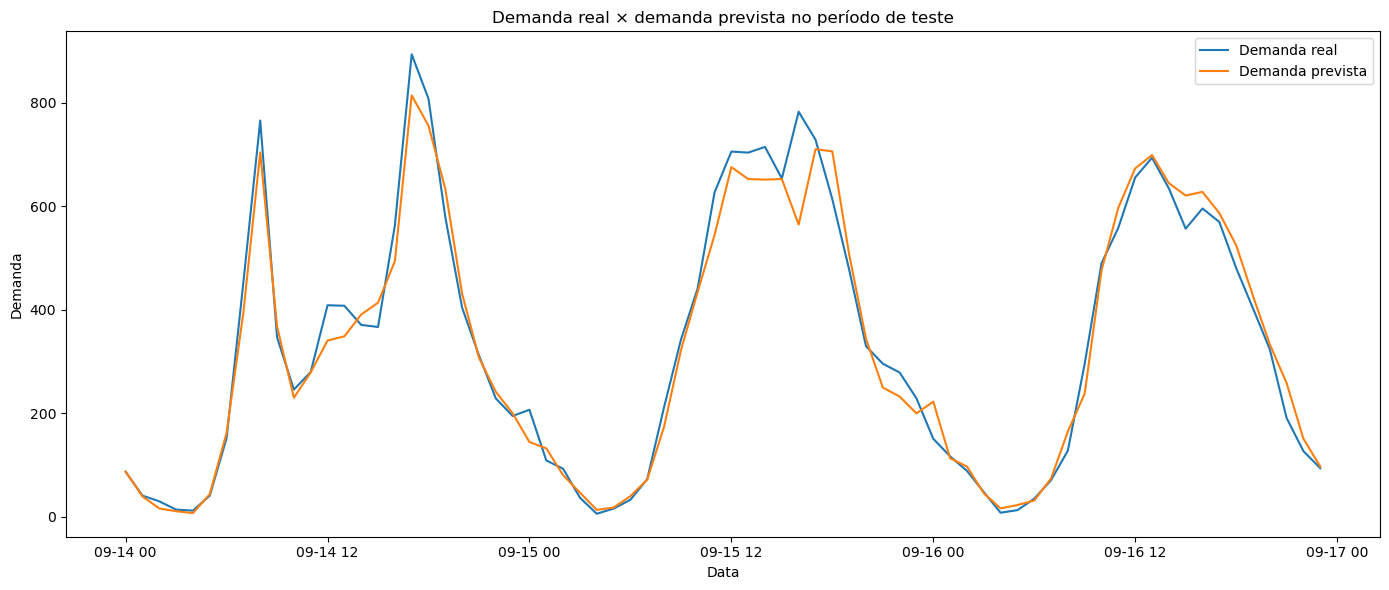

In [37]:
df_low_demand_by_hour = demand_by_hour(2012, 9, 14, 16)
plot_demand(df_low_demand_by_hour, 'hour')

# Feature Importance

Após analisar as features mais importantes para o modelo, destacam-se `lag_1`, `lag_168`, `lag_24`, `hour` e `rolling_median_6`, que, em conjunto, representam 93,85% da importância calculada pelo modelo.

In [41]:
df_feature_importance = pd.Series(rf_best.feature_importances_, index=X_train.columns)
df_feature_importance.sort_values(ascending=False)

lag_1                 0.667734
lag_168               0.151229
lag_24                0.054707
hour                  0.044881
rolling_median_6      0.019933
rolling_max_6         0.007503
lag_6                 0.007069
working_day           0.005414
rolling_std_6         0.004835
feeling_temp          0.004179
rolling_max_24        0.004007
instant               0.003425
rolling_mean_6        0.003287
rolling_std_24        0.002637
hum                   0.002505
rolling_min_6         0.002289
rolling_std_168       0.001929
rolling_mean_24       0.001887
weather_sit           0.001872
rolling_median_24     0.001833
rolling_max_168       0.001419
rolling_median_168    0.001212
rolling_mean_168      0.001149
rolling_min_24        0.000908
wind_speed            0.000826
month                 0.000640
rolling_min_168       0.000303
season                0.000226
year                  0.000146
holiday               0.000016
dtype: float64

# Simulação de previsão

In [39]:
windows = [6, 24, 168]
df_sim_real = create_rolling_features(df_sim_real, windows)

lags = [1, 6, 24, 168]
df_sim_real = create_lags(df_sim_real, lags)

df_sim_real = df_sim_real.drop(columns=['casual', 'registered', 'temp', 'datetime', 'weekday']).iloc[168:]

df_sim_real.shape

(24, 31)

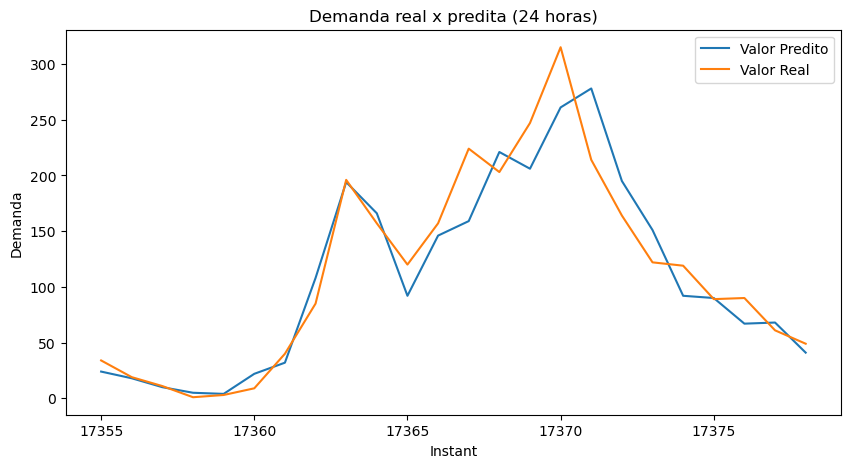

In [40]:
y_pred = rf_best.predict(df_sim_real.drop(columns=[TARGET_COLUMN]))
y_true = df_sim_real[TARGET_COLUMN]

df_result_sim = pd.DataFrame({'Valor Predito': y_pred.round(), 'Valor Real': y_true})


plt.figure(figsize=(10, 5))

sns.lineplot(data=df_result_sim, x=df_result_sim.index, y='Valor Predito', label='Valor Predito')
sns.lineplot(data=df_result_sim, x=df_result_sim.index, y='Valor Real', label='Valor Real')

plt.xlabel('Instant')
plt.ylabel('Demanda')
plt.title('Demanda real x predita (24 horas)')
plt.legend()
plt.show()